# Rendering

cadjoint renders SDF scenes two ways, and this notebook covers both:

- **Forward raymarcher** — a JAX image renderer (early-exit sphere tracing,
  reconstructed silhouettes, GGX materials, soft shadows, reflections, refraction)
  that produces an array you can display or save.
- **WebGPU viewer** — the same scene compiled through StableHLO to WGSL and
  rendered live in the browser, with orbit/zoom/pan controls.

Geometry and constraints stay JAX-native and differentiable; rendered pixels are
deliberately *not* an optimization interface.

## Forward rendering

A scene groups geometry, camera, lights, and environment. Quality lives in a
separate `RenderSettings`, so the same scene can be drawn at any fidelity.

In [1]:
from time import perf_counter

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

from cadjoint.render import Camera, Material, RenderSettings, Scene, make_gradient_sky, render_scene
from cadjoint.sdf.boolean import Union
from cadjoint.sdf.primitives import Plane, Sphere, Torus
from cadjoint.sdf.transforms import Rotate, Translate

In [2]:
ground_height = -0.92
geometry = Union(
    Translate(
        Sphere(0.82, material=Material(color=[0.78, 0.06, 0.025], roughness=0.42)),
        [-1.45, -0.098, 0.0],
    ),
    Translate(
        Rotate(
            Torus(
                0.62,
                0.23,
                material=Material(
                    color=[1.0, 0.58, 0.08], roughness=0.28, metallic=0.8, reflectivity=0.35
                ),
            ),
            axis="y",
            angle=0.45,
        ),
        [0.0, -0.068, 0.0],
    ),
    Translate(
        Sphere(0.78, material=Material(color=[0.035, 0.18, 0.72], roughness=0.28)),
        [1.4, -0.138, 0.0],
    ),
    Plane(ground_height, material=Material(color=[0.1, 0.12, 0.16], roughness=0.72)),
    smoothness=0.0,
)
scene = Scene(
    geometry,
    camera=Camera(position=(4.4, 3.5, 7.5), target=(0.0, -0.35, 0.0), fov=0.38),
    light_directions=((0.35, 1.0, 0.55), (-0.65, 0.45, -0.2), (0.15, 0.2, 1.0)),
    light_colors=((1.5, 1.35, 1.15), (0.22, 0.3, 0.5), (0.2, 0.23, 0.3)),
    environment_map=make_gradient_sky(
        sky_color=(0.7, 0.76, 0.88),
        horizon_color=(0.18, 0.27, 0.44),
        ground_color=(0.16, 0.18, 0.24),
    ),
)

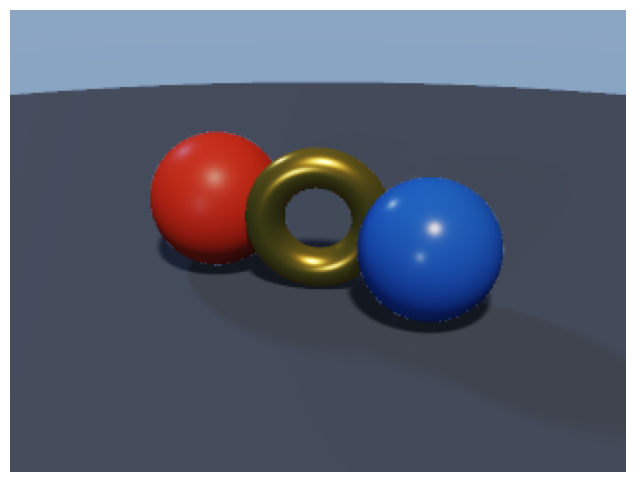

In [3]:
image = render_scene(scene, RenderSettings.balanced((240, 320)))
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off");

## Quality presets

The named presets make the performance/fidelity trade-off explicit. `draft` uses
direct lighting with a shorter trace budget, `balanced` enables soft shadows and
2×2 supersampling, and `high_quality` adds tighter precision and 3×3
supersampling. They are immutable dataclasses, so use `dataclasses.replace` for
scene-specific changes. Each distinct static preset compiles once; the timings
below are steady-state medians after that compile.

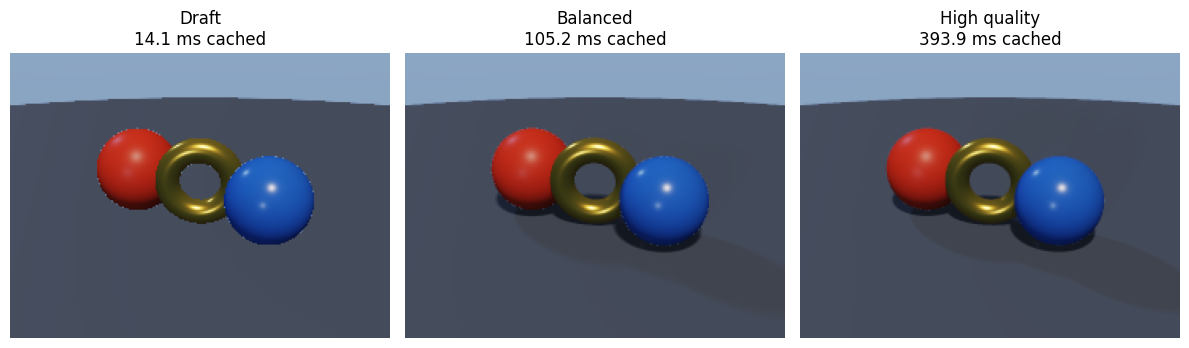

In [4]:
presets = {
    "Draft": RenderSettings.draft((180, 240)),
    "Balanced": RenderSettings.balanced((180, 240)),
    "High quality": RenderSettings.high_quality((180, 240)),
}
images, steady_ms = {}, {}
for name, preset in presets.items():
    images[name] = render_scene(scene, preset)  # compile / warm up
    timings = []
    for _ in range(5):
        start = perf_counter()
        images[name] = render_scene(scene, preset)
        timings.append((perf_counter() - start) * 1e3)
    steady_ms[name] = np.median(timings)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for axis, (name, rendered) in zip(axes, images.items()):
    axis.imshow(rendered)
    axis.set_title(f"{name}\n{steady_ms[name]:.1f} ms cached")
    axis.axis("off")
plt.tight_layout()

## Compile once, render repeatedly

The first call includes JAX compilation. Later calls with the same scene, image
shape, and static feature set reuse the module-level compiled renderer.

In [5]:
settings = RenderSettings.balanced((128, 160))
start = perf_counter()
render_scene(scene, settings)
compile_and_render_ms = (perf_counter() - start) * 1e3

samples = []
for _ in range(10):
    start = perf_counter()
    render_scene(scene, settings)
    samples.append((perf_counter() - start) * 1e3)

print(f"first call: {compile_and_render_ms:.1f} ms")
print(f"cached median: {np.median(samples):.2f} ms")

first call: 559.5 ms
cached median: 52.77 ms


## Early termination

A direct sphere hit should consume only a small fraction of the available step
budget. Misses also stop at `max_distance` rather than evaluating the SDF for
every configured step.

In [6]:
from cadjoint.render.raymarch import _sphere_trace


def sphere_sdf(point):
    return jnp.linalg.norm(point) - 1.0


hit = _sphere_trace(
    sphere_sdf, jnp.array([0.0, 0.0, 5.0]), jnp.array([0.0, 0.0, -1.0]), max_steps=96
)
miss = _sphere_trace(
    sphere_sdf, jnp.array([0.0, 5.0, 0.0]), jnp.array([0.0, 0.0, 1.0]), max_steps=96
)
print(f"hit: distance={float(hit.distance):.3f}, steps={int(hit.steps)}, hit={bool(hit.hit)}")
print(f"miss: distance={float(miss.distance):.3f}, steps={int(miss.steps)}, hit={bool(miss.hit)}")

hit: distance=4.000, steps=4, hit=True
miss: distance=20.000, steps=4, hit=False


## Interactive WebGPU viewer

The same scenes can be compiled to **WebGPU Shading Language (WGSL)** through
JAX's StableHLO export and rendered live in the browser with `SDFViewer`:

```
JAX scene  →  jax.export  →  StableHLO MLIR  →  WGSL  →  WebGPU fragment shader
```

Needs the viewer extra (`uv sync --extra viewer`) and a WebGPU-capable browser
(Chrome/Edge 113+).

**Controls** — left-drag: orbit · scroll: zoom · right-drag: pan · double-click: reset

In [7]:
from cadjoint.backends.wgsl import compile_sdf_to_wgsl
from cadjoint.sdf.boolean import Difference
from cadjoint.sdf.primitives import Box, Capsule
from cadjoint.viewer import SDFViewer

SDFViewer(Sphere(1.0))

### Boolean operations

`smoothness` blends the operands instead of producing a hard seam.

In [8]:
sphere = Sphere(1.0)
box = Translate(Box([1.3, 1.3, 1.3]), offset=jnp.array([0.5, 0.3, 0.0]))

SDFViewer(Union(sphere, box, smoothness=0.2))

In [9]:
SDFViewer(Difference(sphere, box, smoothness=0.05))

### Complex scene — blob of spheres

The entire tree is compiled to a single WGSL function — the GPU evaluates the SDF
directly with no intermediate mesh.

In [10]:
blob = Union(
    Sphere(0.80),
    Translate(Sphere(0.70), offset=jnp.array([1.2, 0.2, 0.0])),
    Translate(Sphere(0.55), offset=jnp.array([0.5, 0.9, -0.7])),
    Translate(Sphere(0.50), offset=jnp.array([-1.0, 0.4, 0.5])),
    Translate(Sphere(0.40), offset=jnp.array([0.1, 1.3, 0.3])),
    smoothness=0.30,
)

cutter = Translate(Box([0.9, 0.28, 0.9]), offset=jnp.array([0.9, 1.0, 0.4]))
SDFViewer(Difference(blob, cutter, smoothness=0.05), height=400)

### Hot-reload — edit the scene without losing camera state

Create a viewer once, then call `update_scene()` to swap in a new SDF. The camera
stays where it is; only the shader recompiles.

In [11]:
viewer = SDFViewer(Sphere(1.0))
viewer

In [12]:
# Run this cell to swap the scene — the viewer above updates instantly
viewer.update_scene(
    Union(
        Sphere(0.9),
        Translate(Capsule(radius=0.3, height=1.4), offset=jnp.array([1.2, 0.0, 0.0])),
        smoothness=0.15,
    )
)

## Inspect the compiled WGSL

`compile_sdf_to_wgsl` returns the raw shader source — useful for debugging or for
exporting to a standalone WebGPU application.

In [13]:
print(compile_sdf_to_wgsl(Union(sphere, box, smoothness=0.1)))

fn sdf___where_1(_arg0: bool, _arg1: f32, _arg2: f32) -> f32 {
    let _v0: f32 = select(_arg2, _arg1, _arg0);
    return _v0;
}

fn sdf___where(_arg0: bool, _arg1: f32, _arg2: f32) -> f32 {
    let _v0: f32 = f32(_arg1);
    let _v1: f32 = select(_arg2, _v0, _arg0);
    return _v1;
}

fn sdf__norm(_arg0: vec3<f32>) -> f32 {
    let _v0: f32 = 0.000000;
    let _v1: vec3<f32> = _arg0 * _arg0;
    let _v2: f32 = _v0 + dot(_v1, vec3<f32>(1.0, 1.0, 1.0));
    let _v3: f32 = sqrt(_v2);
    return _v3;
}

fn sdf(p: vec3<f32>) -> f32 {
    let _v0: f32 = 0.250000;
    let _v1: f32 = 1e-10;
    let _v2: f32 = 4.000000;
    let _v3: f32 = 0.000000;
    let _v4: f32 = -3.402823e38;
    let _v5: f32 = 1.000000;
    let _v6: vec3<f32> = vec3<f32>(0.500000, 0.300000, 0.000000);
    let _v7: vec3<f32> = vec3<f32>(1.300000, 1.300000, 1.300000);
    let _v8: f32 = 0.100000;
    let _v9: f32 = sdf__norm(p);
    let _v10: f32 = f32(_v5);
    let _v11: f32 = _v9 - _v10;
    let _v12: vec3<f32> = p - _v6